In [23]:
!pip install tensorflow missingno fancyimpute


[notice] A new release of pip is available: 24.0 -> 24.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [24]:
#!wget https://raw.githubusercontent.com/opencampus-sh/einfuehrung-in-data-science-und-ml/main/wetter.csv
#!wget https://raw.githubusercontent.com/opencampus-sh/einfuehrung-in-data-science-und-ml/main/kiwo.csv
#!wget https://raw.githubusercontent.com/opencampus-sh/einfuehrung-in-data-science-und-ml/main/umsatzdaten_gekuerzt.csv

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

weather_df = pd.read_csv("wetter.csv")
kiwo_df = pd.read_csv("kiwo.csv")
sales_df = pd.read_csv("umsatzdaten_gekuerzt.csv")
holidays_df = pd.read_csv("../0_DataPreparation/holidays.csv")

print("Weather")
print(f" has {len(weather_df)} rows")
print(weather_df.head())
print("Kieler Woche")
print(f" has {len(kiwo_df)} rows")
print(kiwo_df.head())
print("Sales")
print(f" has {len(sales_df)} rows")
print(sales_df.head())
print("Holidays")
print(f" has {len(holidays_df)} rows")
print(holidays_df.head())

Weather
 has 2601 rows
        Datum  Bewoelkung  Temperatur  Windgeschwindigkeit  Wettercode
0  2012-01-01         8.0      9.8250                   14        58.0
1  2012-01-02         7.0      7.4375                   12         NaN
2  2012-01-03         8.0      5.5375                   18        63.0
3  2012-01-04         4.0      5.6875                   19        80.0
4  2012-01-05         6.0      5.3000                   23        80.0
Kieler Woche
 has 72 rows
        Datum  KielerWoche
0  2012-06-16            1
1  2012-06-17            1
2  2012-06-18            1
3  2012-06-19            1
4  2012-06-20            1
Sales
 has 9334 rows
        Datum  Warengruppe      Umsatz
0  2013-07-01            1  148.828353
1  2013-07-02            1  159.793757
2  2013-07-03            1  111.885594
3  2013-07-04            1  168.864941
4  2013-07-05            1  171.280754
Holidays
 has 577 rows
         date  summer  autumn  christmas  winter  easter  pentecoast
0  2013-06-24   

In [26]:
df = weather_df.merge(kiwo_df, on="Datum", how="left").merge(sales_df, on="Datum").merge(holidays_df, left_on="Datum", right_on="date", suffixes=("", "holiday_",))
df.fillna({"KielerWoche": 0, "holiday_sommer": 0, "holiday_autumn": 0, "holiday_christmas": 0, "holiday_winter": 0, "holiday_easter": 0, "holiday_pentecoast": 0}, inplace=True)
print(df.head())

        Datum  Bewoelkung  Temperatur  Windgeschwindigkeit  Wettercode  \
0  2013-07-01         6.0     17.8375                   15        20.0   
1  2013-07-01         6.0     17.8375                   15        20.0   
2  2013-07-01         6.0     17.8375                   15        20.0   
3  2013-07-01         6.0     17.8375                   15        20.0   
4  2013-07-01         6.0     17.8375                   15        20.0   

   KielerWoche  Warengruppe      Umsatz        date  summer  autumn  \
0          0.0            1  148.828353  2013-07-01       1       0   
1          0.0            2  535.856285  2013-07-01       1       0   
2          0.0            3  201.198426  2013-07-01       1       0   
3          0.0            4   65.890169  2013-07-01       1       0   
4          0.0            5  317.475875  2013-07-01       1       0   

   christmas  winter  easter  pentecoast  
0          0       0       0           0  
1          0       0       0           0  

In [27]:
df['Datum_dt'] = pd.to_datetime(df['Datum'])
df["StartOfMonth"] = np.where(df["Datum_dt"].dt.day < 7, 1, 0)

In [28]:
print("Unique Values:\n",df[["Wettercode", "Bewoelkung"]].apply(lambda x: x.unique()))

Unique Values:
 Wettercode    [20.0, nan, 61.0, 5.0, 21.0, 65.0, 63.0, 10.0,...
Bewoelkung        [6.0, 3.0, 7.0, 5.0, 0.0, 2.0, 1.0, 4.0, 8.0]
dtype: object


<Axes: >

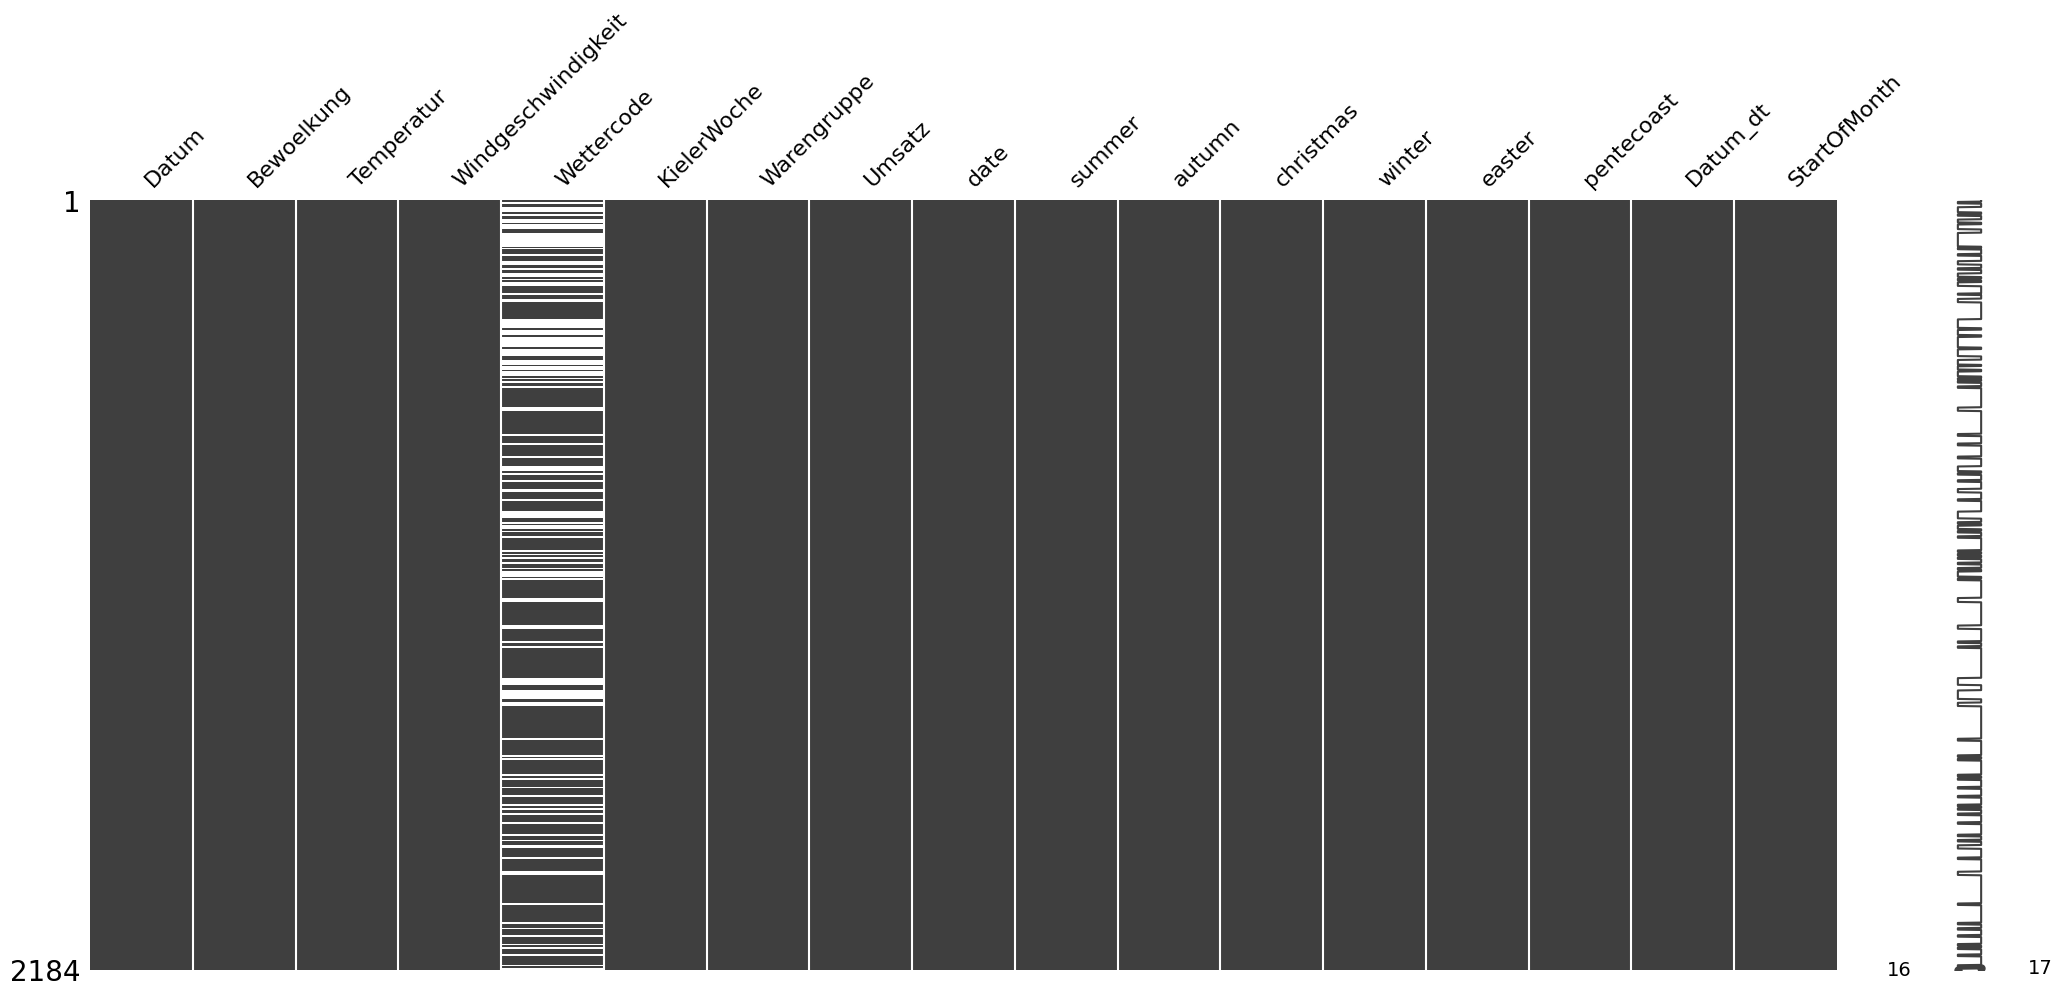

In [29]:
import missingno as msno

msno.matrix(df)

In [30]:
from fancyimpute import IterativeImputer, KNN
imputer = IterativeImputer()
imputer_df = df.drop(["Datum", "date", "Datum_dt"], axis=1)
mask = df["Wettercode"].isna()
#imputed_df = pd.DataFrame(imputer.fit_transform(imputer_df), columns=imputer_df.columns)

In [31]:
imputer_knn = KNN()
imputed_df = pd.DataFrame(imputer_knn.fit_transform(imputer_df), columns=imputer_df.columns)

Imputing row 1/2184 with 0 missing, elapsed time: 0.770
Imputing row 101/2184 with 1 missing, elapsed time: 0.772
Imputing row 201/2184 with 0 missing, elapsed time: 0.773
Imputing row 301/2184 with 0 missing, elapsed time: 0.774
Imputing row 401/2184 with 1 missing, elapsed time: 0.775
Imputing row 501/2184 with 0 missing, elapsed time: 0.777
Imputing row 601/2184 with 0 missing, elapsed time: 0.778
Imputing row 701/2184 with 0 missing, elapsed time: 0.778
Imputing row 801/2184 with 0 missing, elapsed time: 0.779
Imputing row 901/2184 with 1 missing, elapsed time: 0.780
Imputing row 1001/2184 with 0 missing, elapsed time: 0.781
Imputing row 1101/2184 with 0 missing, elapsed time: 0.781
Imputing row 1201/2184 with 0 missing, elapsed time: 0.782
Imputing row 1301/2184 with 0 missing, elapsed time: 0.782
Imputing row 1401/2184 with 1 missing, elapsed time: 0.783
Imputing row 1501/2184 with 0 missing, elapsed time: 0.784
Imputing row 1601/2184 with 0 missing, elapsed time: 0.784
Imputing 

Text(0.5, 1.0, 'Imputed Weathercode')

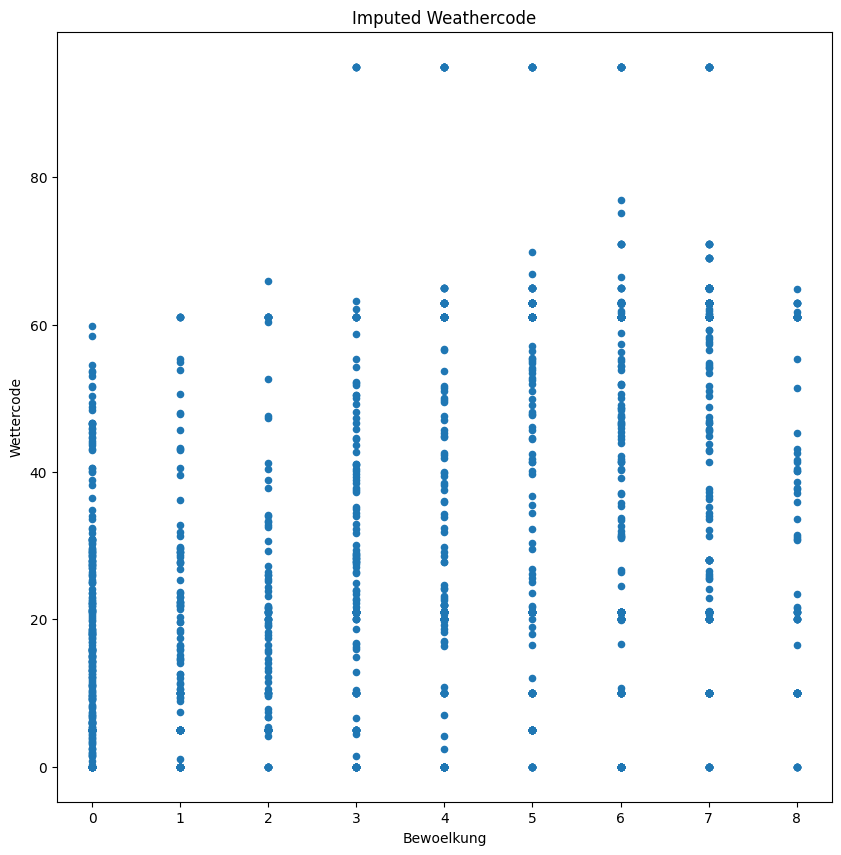

In [32]:
#imputed_df["Datum"] = df["Datum"]
ax = pd.DataFrame(imputed_df).plot(x='Bewoelkung',y='Wettercode',kind='scatter',figsize=(10,10))
ax.set_title("Imputed Weathercode")

In [33]:
import seaborn as sns
# Define a function for scatter plots that highlights imputed values
def plot_scatter_with_imputation(data, x, y, mask, title='Scatter Plot', xlabel='X-axis', ylabel='Y-axis'):
    plt.figure(figsize=(10, 6))
    # Plot non-imputed points
    sns.scatterplot(x=data.loc[~mask, x], y=data.loc[~mask, y], color='blue', label='Original')
    # Plot imputed points
    sns.scatterplot(x=data.loc[mask, x], y=data.loc[mask, y], color='red', label='Imputed')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

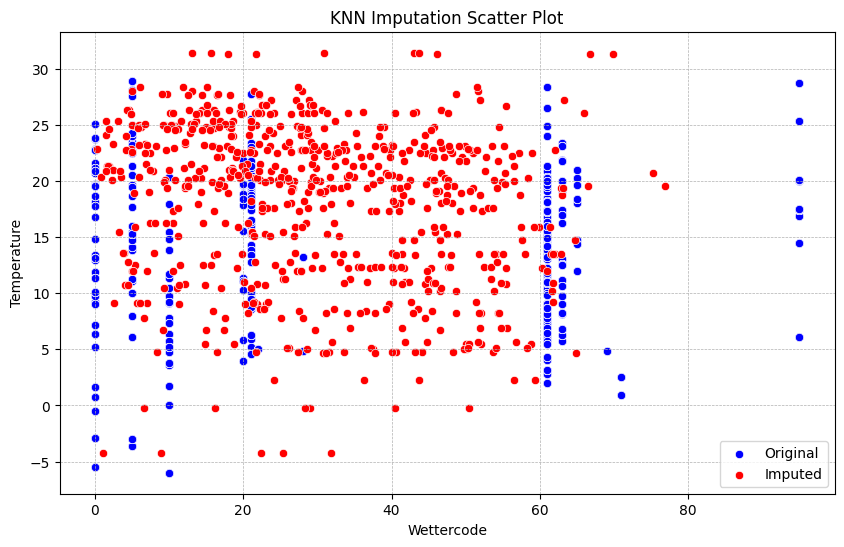

In [34]:
plot_scatter_with_imputation(imputed_df, 'Wettercode', 'Temperatur', mask, 'KNN Imputation Scatter Plot', 'Wettercode', 'Temperature')

In [35]:
print("Correlation in original data:", df['Wettercode'].corr(df['Temperatur'], method='pearson'))
print("Correlation after iterative imputation:", imputed_df['Wettercode'].corr(imputed_df['Temperatur']))

Correlation in original data: -0.04147445109670681
Correlation after iterative imputation: -0.09860295127146157


In [36]:
# Define categorical features
categorical_features = ['Warengruppe']

# Inspect data types and unique values for categorical columns
print(df[categorical_features].dtypes)
print("Unique Values:\n",df[categorical_features].apply(lambda x: x.unique()))

# Ensure categorical columns are treated as categories
for col in categorical_features:
    df[col] = df[col].astype('category')

# Encode categorical variables using pd.get_dummies
features = pd.get_dummies(df[categorical_features], drop_first=True, dtype=int)

# Include any numeric columns that are not categorical
for f in ["summer", "autumn", "StartOfMonth"]:
    features[f] = df[f]

# Construct the prepared data set including the dependent variable ('label')
prepared_data = pd.concat([df[['Umsatz', 'Datum_dt']], features], axis=1).dropna()

# Handle missing values by removing rows with any missing values
prepared_data = prepared_data.dropna()

# Display the shape of the prepared data set
print(prepared_data.shape)
# Display the first few rows of the prepared data set
prepared_data.head()

Warengruppe    int64
dtype: object
Unique Values:
    Warengruppe
0            1
1            2
2            3
3            4
4            5
5            6
(2184, 10)


,Umsatz,Datum_dt,Warengruppe_2,Warengruppe_3,Warengruppe_4,Warengruppe_5,Warengruppe_6,summer,autumn,StartOfMonth
0,148.828353,2013-07-01,0,0,0,0,0,1,0,1
1,535.856285,2013-07-01,1,0,0,0,0,1,0,1
2,201.198426,2013-07-01,0,1,0,0,0,1,0,1
3,65.890169,2013-07-01,0,0,1,0,0,1,0,1
4,317.475875,2013-07-01,0,0,0,1,0,1,0,1


In [37]:
training_data = prepared_data[(prepared_data["Datum_dt"] >= "01.07.2013") & (prepared_data["Datum_dt"] <= "31.07.2017")]
validation_data = prepared_data[(prepared_data["Datum_dt"] >= "01.08.2017") & (prepared_data["Datum_dt"] <= "31.07.2018")]

print(f"Training Dataset length: {len(training_data)}")
print(f"Validation Dataset length: {len(validation_data)}")


print(training_data.dtypes)
training_data.sample()

Training Dataset length: 1694
Validation Dataset length: 605
Umsatz                  float64
Datum_dt         datetime64[ns]
Warengruppe_2             int64
Warengruppe_3             int64
Warengruppe_4             int64
Warengruppe_5             int64
Warengruppe_6             int64
summer                    int64
autumn                    int64
StartOfMonth              int64
dtype: object


,Umsatz,Datum_dt,Warengruppe_2,Warengruppe_3,Warengruppe_4,Warengruppe_5,Warengruppe_6,summer,autumn,StartOfMonth
1679,202.431896,2017-07-29,0,0,0,0,0,1,0,0


In [38]:
# Create subdirectory for the pickle files
import os

subdirectory = "pickle_data"
os.makedirs(subdirectory, exist_ok=True)

# Separating features and labels
training_features = training_data.drop(['Umsatz', 'Datum_dt'], axis=1)
validation_features = validation_data.drop(['Umsatz', 'Datum_dt'], axis=1)

training_labels = training_data[['Umsatz']]
validation_labels = validation_data[['Umsatz']]

# Export of the prepared data to subdirectory as pickle files
training_features.to_pickle(f"{subdirectory}/training_features.pkl")
validation_features.to_pickle(f"{subdirectory}/validation_features.pkl")
training_labels.to_pickle(f"{subdirectory}/training_labels.pkl")
validation_labels.to_pickle(f"{subdirectory}/validation_labels.pkl")

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
  InputLayer(input_shape=(training_features.shape[1], )),
  BatchNormalization(),
  Dense(10, activation='relu'),
  Dropout(.3),
  Dense(4, activation='relu'),
  Dense(1)
])

model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171 (684.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 16 (64.00 B)

In [40]:
model.compile(loss="mse", optimizer=Adam(learning_rate=0.0001))

history = model.fit(training_features, training_labels, epochs=1000,
                    validation_data=(validation_features, validation_labels))

Epoch 1/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 103839.6641 - val_loss: 83902.4766
Epoch 2/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 93283.8984 - val_loss: 83818.9375
Epoch 3/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 105450.9688 - val_loss: 83733.8750
Epoch 4/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 96145.2656 - val_loss: 83650.4844
Epoch 5/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 99230.6484 - val_loss: 83567.5859
Epoch 6/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 95844.1641 - val_loss: 83490.1719
Epoch 7/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99018.7812 - val_loss: 83416.1641
Epoch 8/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 96515.4453 - val_loss: 83345.8828
Epoch 9/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99651.2266 - val_loss: 83274.5859
Epoch 10/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 100707.9688 - val_loss: 83204.1250
Epoch 11/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - l

In [41]:
model.save("python_model.h5")

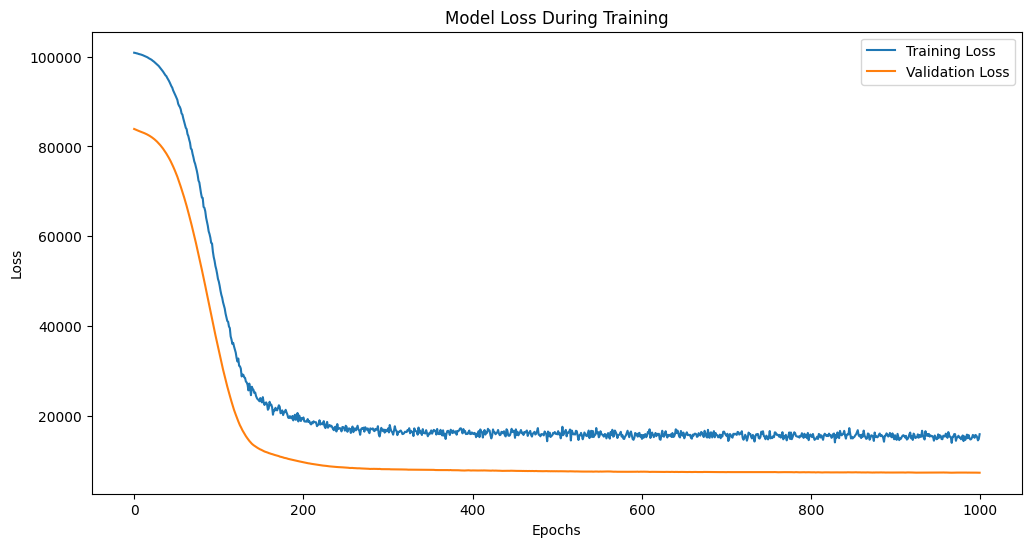

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [43]:
predict_val = model.predict(validation_features)
validation_features["Forecast"] = predict_val
validation_features["Diff"] = validation_features["Forecast"] - validation_labels["Umsatz"]
print(validation_features["Diff"])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1579    -34.002139
1580    120.630012
1581     51.551164
1582     -3.791725
1583     63.776702
           ...    
2179     65.125307
2180    -61.979310
2181    -36.576519
2182     38.317402
2183     77.518978
Name: Diff, Length: 605, dtype: float64


Text(0.5, 1.0, 'Comparison Actual Revenue vs. Forecast')

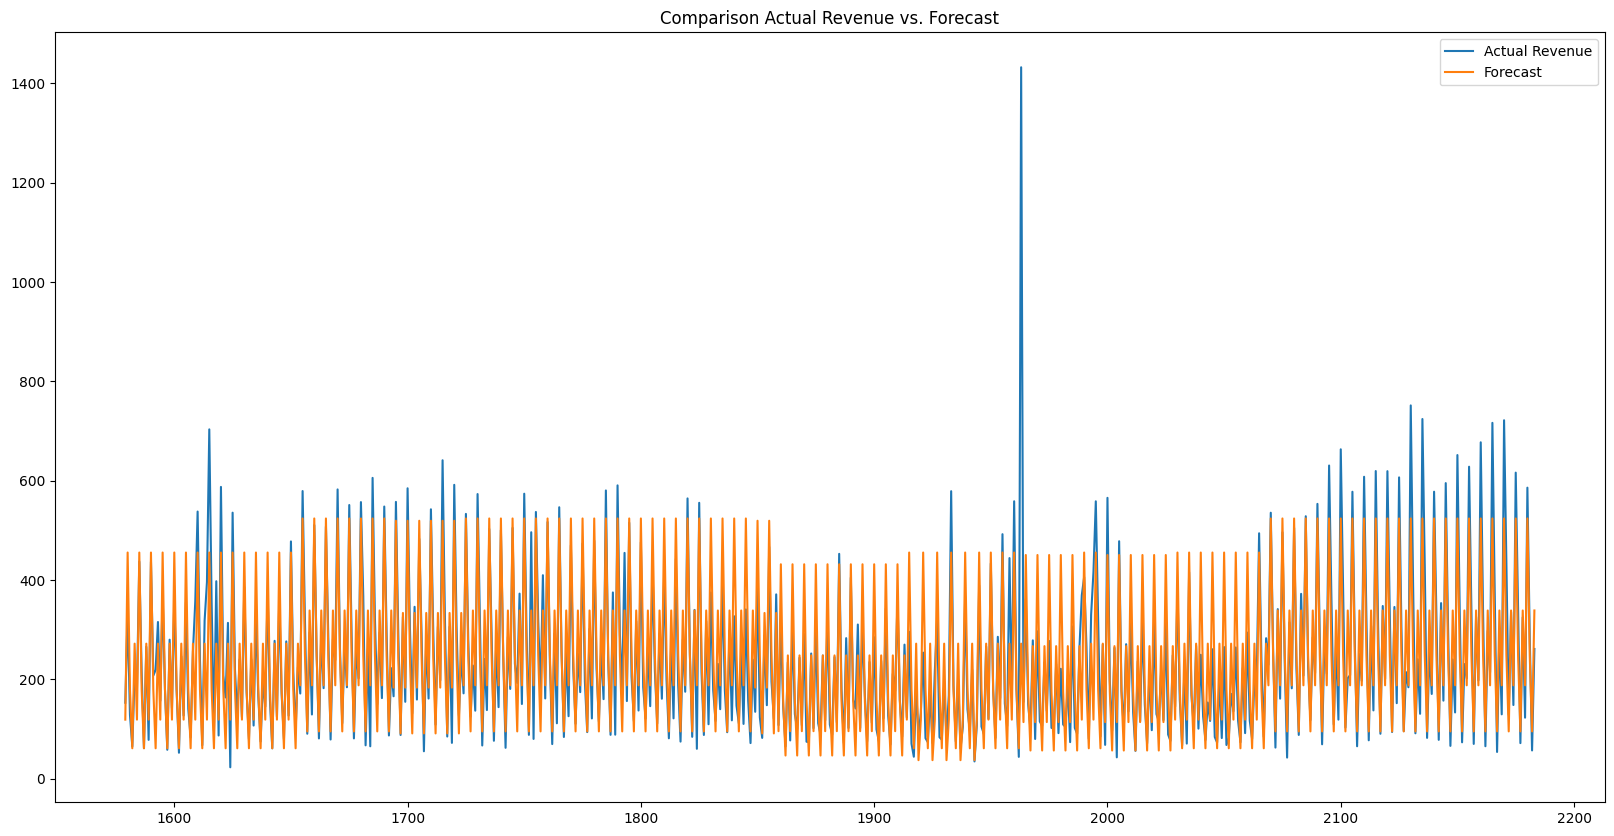

In [44]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 10)
ax.plot(validation_features.index, validation_labels["Umsatz"], label="Actual Revenue")
ax.plot(validation_features.index, validation_features["Forecast"], label="Forecast")
ax.legend(loc="upper right")
ax.set_title("Comparison Actual Revenue vs. Forecast")